# **ARIMA AS BASELINE**

# MOUNT DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# INSTALL / LOAD R SUPPORT

In [2]:
!pip install -q rpy2

# IMPORT PYTHON LIBRARIES

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ENABLE R IN COLAB

In [4]:
%load_ext rpy2.ipython

# INSTALL/LOAD R PACKAGES

In [5]:
%%R
if (!require(forecast)) install.packages("forecast", repos="https://cloud.r-project.org")
if (!require(ggplot2)) install.packages("ggplot2", repos="https://cloud.r-project.org")
if (!require(tseries)) install.packages("tseries", repos="https://cloud.r-project.org")

library(forecast)
library(ggplot2)
library(tseries)

Loading required package: forecast
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’

trying URL 'https://cloud.r-project.org/src/contrib/colorspace_2.1-2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/fracdiff_1.5-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/lmtest_0.9-40.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/timeDate_4052.112.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/urca_1.3-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppArmadillo_15.2.7-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/forecast_9.0.2.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpVuQ3zM/downloaded_packages’
Loading required package: ggplot2
Loading required package: tseries
Installing package i

# LOAD MALAYSIA DATASET

In [6]:
path = "/content/drive/MyDrive/FYP_2026/DATA/FINAL_DATASETS/malaysia_ready_for_model.csv"

df = pd.read_csv(path)
df = df.sort_values("Year").reset_index(drop=True)

print("First year:", df["Year"].min())
print("Last year :", df["Year"].max())
print("Total rows:", len(df))

display(df.head())

First year: 1992
Last year : 2022
Total rows: 31


,Year,CO2,GDP,Population,Energy_Use,Log_CO2,Log_GDP,Log_Population,Log_Energy_Use,Log_CO2_Lag1,Log_GDP_Lag1,Log_Pop_Lag1,Log_Energy_Lag1,Log_CO2_Lag2
0,1992,72961016.0,8.901478e+10,18834572.0,1542.601653,18.105436,25.212068,16.751205,7.341874,18.001904,25.126945,16.724729,7.268426,17.809470
1,1993,86612380.0,9.782275e+10,19322664.0,1628.856475,18.276953,25.306423,16.776789,7.396247,18.105436,25.212068,16.751205,7.341874,18.001904
2,1994,87497430.0,1.068342e+11,19820446.0,1579.983076,18.287120,25.394544,16.802225,7.365802,18.276953,25.306423,16.776789,7.396247,18.105436
3,1995,109595210.0,1.173350e+11,20330599.0,1669.430762,18.512304,25.488299,16.827638,7.420837,18.287120,25.394544,16.802225,7.365802,18.276953
4,1996,110108470.0,1.290717e+11,20850087.0,1804.841510,18.516977,25.583634,16.852869,7.498782,18.512304,25.488299,16.827638,7.420837,18.287120


# SET OUTPUT PATHS

In [7]:
metrics_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA"
forecast_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA"
visualization_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA"

os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(forecast_dir, exist_ok=True)
os.makedirs(visualization_dir, exist_ok=True)

print("Metrics dir:", metrics_dir)
print("Forecast dir:", forecast_dir)
print("Visualization dir:", visualization_dir)

Metrics dir: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA
Forecast dir: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA
Visualization dir: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA


# =========================================
# ARIMA - MALAYSIA ONLY - CO2 ONLY - HOLDOUT
# =========================================



> **HOLDOUT SPLIT**



In [8]:
train_df = df[df["Year"] <= 2019].copy()
test_df = df[(df["Year"] >= 2020) & (df["Year"] <= 2022)].copy()

print("Train years:", train_df["Year"].min(), "-", train_df["Year"].max())
print("Test years :", test_df["Year"].min(), "-", test_df["Year"].max())
print("Train rows :", len(train_df))
print("Test rows  :", len(test_df))

Train years: 1992 - 2019
Test years : 2020 - 2022
Train rows : 28
Test rows  : 3




> **SEND HOLDOUT TO R**



In [9]:
from rpy2.robjects import pandas2ri
pandas2ri.activate()

%R -i train_df -i test_df



> **FIT ARIMA HOULDOUT IN R & CREATE PREDICTIONS**



In [10]:
%%R
# Use Log_CO2 for ARIMA baseline
train_ts <- ts(train_df$Log_CO2, start=min(train_df$Year), frequency=1)

# Auto ARIMA on training period only
arima_holdout_model <- auto.arima(train_ts)

print(summary(arima_holdout_model))

# Forecast the test horizon length
h <- nrow(test_df)
fc_holdout <- forecast(arima_holdout_model, h=h)

# Back-transform predictions to CO2 scale
pred_log <- as.numeric(fc_holdout$mean)
pred_co2 <- (exp(pred_log) - 1) / 1000

# Build prediction table
holdout_pred_df <- data.frame(
  Year = test_df$Year,
  Actual_CO2 = test_df$CO2 / 1000,
  Pred_CO2 = pred_co2
)

print(holdout_pred_df)

Series: train_ts 
ARIMA(0,1,0) with drift 

Coefficients:
       drift
      0.0495
s.e.  0.0135

sigma^2 = 0.005139:  log likelihood = 33.39
AIC=-62.77   AICc=-62.27   BIC=-60.18

Training set error measures:
                       ME       RMSE        MAE         MPE      MAPE      MASE
Training set 0.0006448545 0.06908204 0.05454095 0.004483281 0.2906384 0.8762142
                  ACF1
Training set -0.114553
  Year Actual_CO2 Pred_CO2
1 2020   262158.8 291763.8
2 2021   273332.2 306569.7
3 2022   281883.8 322127.0




> **BRING HOLDOUT PREDICTIONS BACK TO PYTHON**



In [11]:
%R -o holdout_pred_df

holdout_pred_df = holdout_pred_df.sort_values("Year").reset_index(drop=True)
display(holdout_pred_df)

,Year,Actual_CO2,Pred_CO2
0,2020,262158.82,291763.775942
1,2021,273332.16,306569.711886
2,2022,281883.80,322126.994489




> **METRICS**



In [12]:
holdout_rmse = np.sqrt(mean_squared_error(holdout_pred_df["Actual_CO2"], holdout_pred_df["Pred_CO2"]))
holdout_mae = mean_absolute_error(holdout_pred_df["Actual_CO2"], holdout_pred_df["Pred_CO2"])
holdout_mape = np.mean(
    np.abs((holdout_pred_df["Actual_CO2"] - holdout_pred_df["Pred_CO2"]) / holdout_pred_df["Actual_CO2"])
) * 100

arima_holdout_results = pd.DataFrame({
    "Model": ["ARIMA"],
    "Scope": ["Malaysia-only"],
    "Variant": ["Baseline"],
    "Validation": ["Holdout"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["1992-2019"],
    "Test_Period": ["2020-2022"],
    "RMSE": [holdout_rmse],
    "MAE": [holdout_mae],
    "MAPE": [holdout_mape]
})

print("RMSE:", holdout_rmse)
print("MAE :", holdout_mae)
print("MAPE:", holdout_mape)

display(arima_holdout_results)

RMSE: 34644.398173307745
MAE : 34361.90077232703
MAPE: 12.576469087636289


,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,ARIMA,Malaysia-only,Baseline,Holdout,Malaysia,1992-2019,2020-2022,34644.398173,34361.900772,12.576469




> **HOLDOUT SAVE PATHS**



In [13]:
holdout_results_path = os.path.join(metrics_dir, "ARIMA_HOLDOUT_results.csv")
holdout_predictions_path = os.path.join(forecast_dir, "ARIMA_HOLDOUT_predictions.csv")
holdout_plot_path = os.path.join(visualization_dir, "ARIMA_HOLDOUT_plot.png")



> **PLOT GRAPH**



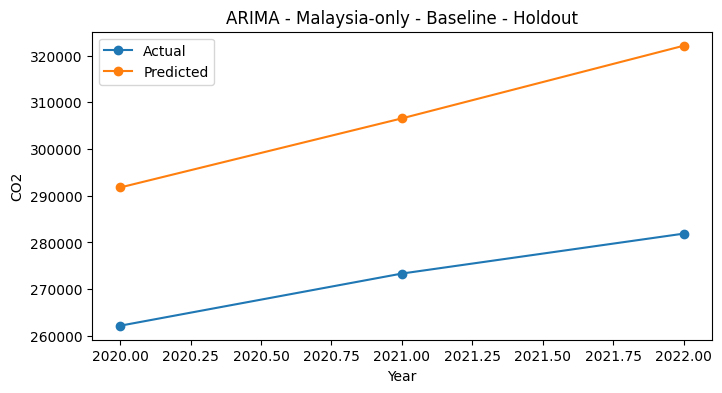

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(holdout_pred_df["Year"], holdout_pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(holdout_pred_df["Year"], holdout_pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("ARIMA - Malaysia-only - Baseline - Holdout")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(holdout_plot_path, dpi=300, bbox_inches="tight")
plt.show()



> **SAVE RESULTS**



In [15]:
arima_holdout_results.to_csv(holdout_results_path, index=False)
holdout_pred_df.to_csv(holdout_predictions_path, index=False)

print("Saved holdout results to:", holdout_results_path)
print("Saved holdout predictions to:", holdout_predictions_path)
print("Saved holdout plot to:", holdout_plot_path)

Saved holdout results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA/ARIMA_HOLDOUT_results.csv
Saved holdout predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA/ARIMA_HOLDOUT_predictions.csv
Saved holdout plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA/ARIMA_HOLDOUT_plot.png


# =========================================
# ARIMA - MALAYSIA ONLY - CO2 ONLY - ROLLING
# =========================================



> **ROLLING R**



In [16]:
# =========================================
# 7. ARIMA ROLLING 1-STEP (FIXED VERSION)
# =========================================

rolling_years = []
rolling_actual = []
rolling_pred = []
rolling_train_start = []
rolling_train_end = []

for i in range(8, len(df)):

    train_part = df.iloc[:i].copy()
    test_part = df.iloc[i:i+1].copy()

    # Send data to R
    %R -i train_part -i test_part

    # Run ARIMA in R (single-line magic)
    %R train_ts_roll <- ts(train_part$Log_CO2, start=min(train_part$Year), frequency=1)
    %R arima_roll_model <- auto.arima(train_ts_roll)
    %R fc_roll <- forecast(arima_roll_model, h=1)
    %R rolling_pred_log <- as.numeric(fc_roll$mean)[1]
    %R rolling_pred_co2 <- (exp(rolling_pred_log) - 1) / 1000

    # Bring prediction back
    %R -o rolling_pred_co2

    rolling_years.append(int(test_part["Year"].iloc[0]))
    rolling_actual.append(float(test_part["CO2"].iloc[0] / 1000))
    rolling_pred.append(float(rolling_pred_co2[0]))

    rolling_train_start.append(int(train_part["Year"].min()))
    rolling_train_end.append(int(train_part["Year"].max()))



> **ROLLING PREDICTION TABLE**



In [17]:
arima_rolling_pred_df = pd.DataFrame({
    "Train_Start": rolling_train_start,
    "Train_End": rolling_train_end,
    "Year": rolling_years,
    "Actual_CO2": rolling_actual,
    "Pred_CO2": rolling_pred
})

arima_rolling_pred_df = arima_rolling_pred_df.sort_values("Year").reset_index(drop=True)
display(arima_rolling_pred_df.head())

,Train_Start,Train_End,Year,Actual_CO2,Pred_CO2
0,1992,1999,2000,122881.384,103986.550000
1,1992,2000,2001,130890.050,122881.384000
2,1992,2001,2002,132035.230,130890.050000
3,1992,2002,2003,153384.340,140103.737690
4,1992,2003,2004,169674.400,164102.988428




> **ROLLING METRICS**



In [18]:
rolling_rmse = np.sqrt(mean_squared_error(
    arima_rolling_pred_df["Actual_CO2"],
    arima_rolling_pred_df["Pred_CO2"]
))
rolling_mae = mean_absolute_error(
    arima_rolling_pred_df["Actual_CO2"],
    arima_rolling_pred_df["Pred_CO2"]
)
rolling_mape = np.mean(
    np.abs(
        (arima_rolling_pred_df["Actual_CO2"] - arima_rolling_pred_df["Pred_CO2"])
        / arima_rolling_pred_df["Actual_CO2"]
    )
) * 100

arima_rolling_results = pd.DataFrame({
    "Model": ["ARIMA"],
    "Scope": ["Malaysia-only"],
    "Variant": ["Baseline"],
    "Validation": ["Rolling"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["Expanding window"],
    "Test_Period": ["Rolling 1-step ahead"],
    "RMSE": [rolling_rmse],
    "MAE": [rolling_mae],
    "MAPE": [rolling_mape]
})

print("RMSE:", rolling_rmse)
print("MAE :", rolling_mae)
print("MAPE:", rolling_mape)

display(arima_rolling_results)

RMSE: 11841.75811581033
MAE : 9456.79445486773
MAPE: 4.850903931830805


,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,ARIMA,Malaysia-only,Baseline,Rolling,Malaysia,Expanding window,Rolling 1-step ahead,11841.758116,9456.794455,4.850904




> **SAVE PATHS**



In [19]:
rolling_results_path = os.path.join(metrics_dir, "ARIMA_ROLLING_results.csv")
rolling_predictions_path = os.path.join(forecast_dir, "ARIMA_ROLLING_predictions.csv")
rolling_plot_path = os.path.join(visualization_dir, "ARIMA_ROLLING_plot.png")



> **PLOT GRAPH**



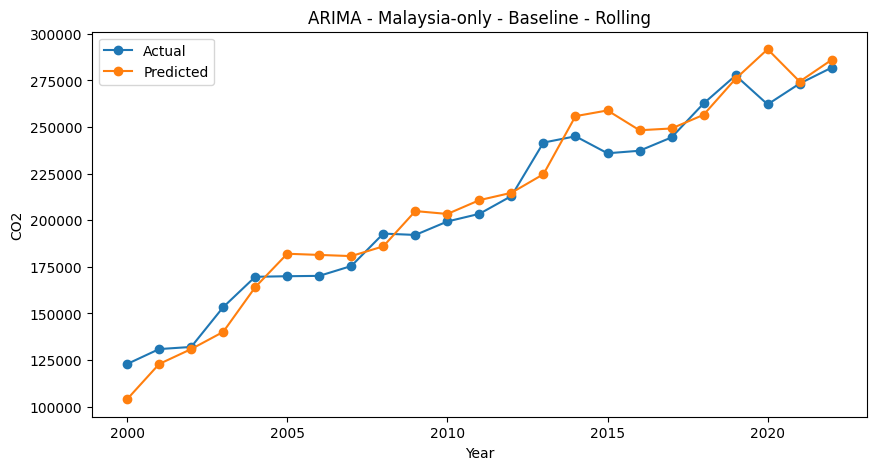

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(arima_rolling_pred_df["Year"], arima_rolling_pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(arima_rolling_pred_df["Year"], arima_rolling_pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("ARIMA - Malaysia-only - Baseline - Rolling")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(rolling_plot_path, dpi=300, bbox_inches="tight")
plt.show()



> **SAVE OUTPUTS**



In [21]:
arima_rolling_results.to_csv(rolling_results_path, index=False)
arima_rolling_pred_df.to_csv(rolling_predictions_path, index=False)

print("Saved rolling results to:", rolling_results_path)
print("Saved rolling predictions to:", rolling_predictions_path)
print("Saved rolling plot to:", rolling_plot_path)

Saved rolling results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA/ARIMA_ROLLING_results.csv
Saved rolling predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA/ARIMA_ROLLING_predictions.csv
Saved rolling plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA/ARIMA_ROLLING_plot.png


# ARIMA FUTURE FORECAST 2023 - 2030



> **SET UP FORECAST**



In [22]:
arima_rolling_results.to_csv(rolling_results_path, index=False)
arima_rolling_pred_df.to_csv(rolling_predictions_path, index=False)

print("Saved rolling results to:", rolling_results_path)
print("Saved rolling predictions to:", rolling_predictions_path)
print("Saved rolling plot to:", rolling_plot_path)

Saved rolling results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA/ARIMA_ROLLING_results.csv
Saved rolling predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA/ARIMA_ROLLING_predictions.csv
Saved rolling plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA/ARIMA_ROLLING_plot.png


In [23]:
full_train_df = df.copy()

print(full_train_df.head())
print("Rows:", len(full_train_df))

   Year          CO2           GDP  Population   Energy_Use    Log_CO2  \
0  1992   72961016.0  8.901478e+10  18834572.0  1542.601653  18.105436   
1  1993   86612380.0  9.782275e+10  19322664.0  1628.856475  18.276953   
2  1994   87497430.0  1.068342e+11  19820446.0  1579.983076  18.287120   
3  1995  109595210.0  1.173350e+11  20330599.0  1669.430762  18.512304   
4  1996  110108470.0  1.290717e+11  20850087.0  1804.841510  18.516977   

     Log_GDP  Log_Population  Log_Energy_Use  Log_CO2_Lag1  Log_GDP_Lag1  \
0  25.212068       16.751205        7.341874     18.001904     25.126945   
1  25.306423       16.776789        7.396247     18.105436     25.212068   
2  25.394544       16.802225        7.365802     18.276953     25.306423   
3  25.488299       16.827638        7.420837     18.287120     25.394544   
4  25.583634       16.852869        7.498782     18.512304     25.488299   

   Log_Pop_Lag1  Log_Energy_Lag1  Log_CO2_Lag2  
0     16.724729         7.268426     17.809470  


In [24]:
%R -i full_train_df

In [25]:
%%R
full_ts <- ts(full_train_df$Log_CO2, start=min(full_train_df$Year), frequency=1)

arima_future_model <- auto.arima(full_ts)

print(summary(arima_future_model))

future_h <- 8   # 2023 to 2030
fc_future <- forecast(arima_future_model, h=future_h)

future_years <- 2023:2030
future_pred_log <- as.numeric(fc_future$mean)
future_pred_co2 <- (exp(future_pred_log) - 1) / 1000

future_forecast_df <- data.frame(
  Year = future_years,
  Forecast_CO2 = future_pred_co2
)

print(future_forecast_df)

Series: full_ts 
ARIMA(0,1,0) with drift 

Coefficients:
       drift
      0.0451
s.e.  0.0127

sigma^2 = 0.004996:  log likelihood = 37.46
AIC=-70.92   AICc=-70.48   BIC=-68.12

Training set error measures:
                       ME       RMSE        MAE         MPE      MAPE      MASE
Training set 0.0005825927 0.06836551 0.05246991 0.004561278 0.2789883 0.8693387
                   ACF1
Training set -0.1103716
  Year Forecast_CO2
1 2023     294873.7
2 2024     308462.3
3 2025     322677.0
4 2026     337546.8
5 2027     353101.8
6 2028     369373.7
7 2029     386395.4
8 2030     404201.5


# BRING BACK TO PYTHON

In [26]:
%R -o future_forecast_df

future_forecast_df = future_forecast_df.sort_values("Year").reset_index(drop=True)
display(future_forecast_df)

,Year,Forecast_CO2
0,2023,294873.735965
1,2024,308462.281839
2,2025,322677.023118
3,2026,337546.816507
4,2027,353101.848507
5,2028,369373.696687
6,2029,386395.393794
7,2030,404201.494811




> **SUMMARY TABLE FOR FUTURE FORECAST**



In [27]:
arima_forecast_results = pd.DataFrame({
    "Model": ["ARIMA"],
    "Scope": ["Malaysia-only"],
    "Variant": ["Baseline"],
    "Validation": ["Future Forecast"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["1992-2022"],
    "Forecast_Period": ["2023-2030"]
})

display(arima_forecast_results)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Forecast_Period
0,ARIMA,Malaysia-only,Baseline,Future Forecast,Malaysia,1992-2022,2023-2030


> **SAVE PATHS**

In [28]:
forecast_results_path = os.path.join(metrics_dir, "ARIMA_FORECAST_2023_2030_results.csv")
forecast_predictions_path = os.path.join(forecast_dir, "ARIMA_FORECAST_2023_2030.csv")
forecast_plot_path = os.path.join(visualization_dir, "ARIMA_FORECAST_2023_2030_plot.png")

> **PLOT HISTORICAL + FUTURE FORECASTS**

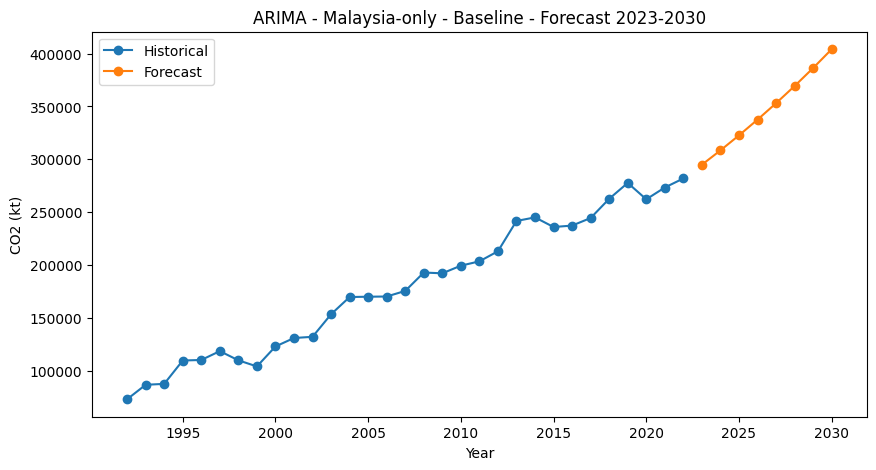

In [29]:
historical_df = df[["Year", "CO2"]].copy()
historical_df = historical_df.sort_values("Year").reset_index(drop=True)

# Convert historical CO2 to kt for consistency
historical_df["CO2"] = historical_df["CO2"] / 1000

plt.figure(figsize=(10, 5))
plt.plot(historical_df["Year"], historical_df["CO2"], marker="o", label="Historical")
plt.plot(future_forecast_df["Year"], future_forecast_df["Forecast_CO2"], marker="o", label="Forecast")

plt.title("ARIMA - Malaysia-only - Baseline - Forecast 2023-2030")
plt.xlabel("Year")
plt.ylabel("CO2 (kt)")
plt.legend()

plt.savefig(forecast_plot_path, dpi=300, bbox_inches="tight")
plt.show()



> **SAVE FUTURE FORECAST OUTPUTS**



In [30]:
arima_forecast_results.to_csv(forecast_results_path, index=False)
future_forecast_df.to_csv(forecast_predictions_path, index=False)

print("Saved forecast summary to:", forecast_results_path)
print("Saved forecast values to:", forecast_predictions_path)
print("Saved forecast plot to:", forecast_plot_path)

Saved forecast summary to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/ARIMA/ARIMA_FORECAST_2023_2030_results.csv
Saved forecast values to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/ARIMA/ARIMA_FORECAST_2023_2030.csv
Saved forecast plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/ARIMA/ARIMA_FORECAST_2023_2030_plot.png
